<a href="https://colab.research.google.com/github/DNL139/pi_tec_BD_supermercado/blob/main/pi_tec_BD_supermercado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto Integrador - Análise de Dados de Supermercado

**Instituição:** SENAC EAD  
**Curso:** Tecnologia em Banco de Dados  
**Disciplina:** PI: Ciência de Dados Aplicada a Situações de Mercado  
**Fonte dos dados:** [Supermarket Sales Dataset - Kaggle](https://www.kaggle.com/datasets/faresashraf1001/supermarket-sales/data)  
**Período analisado:** 1º de janeiro a 30 de março de 2019


## 1. Introdução

Este projeto tem como objetivo desenvolver uma prova de conceito de um modelo de
Inteligência de Negócio (BI), utilizando técnicas de análise exploratória de dados
e visualização de informações.

Para isso, será utilizada uma base de dados contendo informações sobre vendas de
uma rede de supermercados, incluindo características das vendas, clientes, produtos,
filiais, formas de pagamento, valores comercializados e avaliações.

A análise será realizada utilizando as bibliotecas Pandas e NumPy para manipulação
e análise dos dados, e Matplotlib para a criação das visualizações.

Objetivos:
- Realizar análise exploratória de dados (EDA)
- Criar visualizações relevantes para tomada de decisão
- Interpretar os resultados sob a ótica de negócio

In [41]:
# ==========================
# 1. Importação de bibliotecas e Paleta de Cores
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image

# Mapeamento da Paleta de Cores do Senac
AZUL_SENAC = '#004a8d'
LARANJA_SENAC = '#f7941e'
LARANJA_CLARO = '#fdc17f'

In [42]:
# ==========================
# 2. Carregamento da base
# ==========================

caminho_arquivo = 'SuperMarket Analysis.csv'

df = pd.read_csv("/content/SuperMarket Analysis.csv")

In [43]:
# Visualizar primeiras linhas
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [44]:
# Informações gerais do dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

## 2. Limpeza e tratamento dos dados

Nesta etapa vamos:
- Converter colunas de data e hora para tipos adequados
- Verificar valores nulos
- Criar colunas derivadas úteis para análise (ex.: dia da semana, horário)

In [45]:
# ==========================
# 3.1 Conversão de tipos
# ==========================

# Converter coluna Date para datetime
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')

# Converter coluna Time para datetime (apenas hora)
df['Time'] = pd.to_datetime(df['Time']).dt.time

# Conferir novamente
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   object        
 1   Branch                   1000 non-null   object        
 2   City                     1000 non-null   object        
 3   Customer type            1000 non-null   object        
 4   Gender                   1000 non-null   object        
 5   Product line             1000 non-null   object        
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Sales                    1000 non-null   float64       
 10  Date                     1000 non-null   datetime64[ns]
 11  Time                     1000 non-null   object        
 12  Payment                  1000 non-n

/tmp/ipykernel_1076/72588140.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time'] = pd.to_datetime(df['Time']).dt.time


In [46]:
# ==========================
# 3.2 Verificação de nulos e duplicatas
# ==========================

# Verificar valores nulos
print("Valores nulos por coluna:")
print(df.isnull().sum())

# Verificar duplicatas
print("\nRegistros duplicados:", df.duplicated().sum())

# Remover duplicatas, se houver
df = df.drop_duplicates()

Valores nulos por coluna:
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

Registros duplicados: 0


In [47]:
# ==========================
# 3.2.1 Verificação da consistência financeira com NumPy
# ==========================

valores_esperados = df['cogs'] + df['Tax 5%']

vendas_consistentes = np.isclose(
    df['Sales'],
    valores_esperados
)

print(
    "Registros financeiramente consistentes:",
    np.sum(vendas_consistentes)
)

print(
    "Registros financeiramente inconsistentes:",
    np.sum(~vendas_consistentes)
)

Registros financeiramente consistentes: 1000
Registros financeiramente inconsistentes: 0


In [48]:
# ==========================
# 3.3 Criação de colunas derivadas
# ==========================

# Criar coluna de dia da semana
df['DayOfWeek'] = df['Date'].dt.day_name()

# Criar coluna de hora (inteiro)
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour

# Criar coluna de período do dia (manhã/tarde/noite)
def periodo_do_dia(hora):
    if hora < 12:
        return 'Manhã'
    elif hora < 18:
        return 'Tarde'
    else:
        return 'Noite'

df['Period'] = df['Hour'].apply(periodo_do_dia)

df[['Date', 'Time', 'DayOfWeek', 'Hour', 'Period']].head()

,Date,Time,DayOfWeek,Hour,Period
0,2019-01-05,13:08:00,Saturday,13,Tarde
1,2019-03-08,10:29:00,Friday,10,Manhã
2,2019-03-03,13:23:00,Sunday,13,Tarde
3,2019-01-27,20:33:00,Sunday,20,Noite
4,2019-02-08,10:37:00,Friday,10,Manhã


## 3. Análise Exploratória de Dados (EDA)

Nesta etapa, exploramos os principais aspectos da base de dados que serão utilizados nas análises e visualizações do projeto. O foco está em entender o comportamento das vendas por categoria, filial, horário, forma de pagamento e lucro.


In [49]:
# ==========================
# 4.1 Visão geral da base
# ==========================

df.head()
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   object        
 1   Branch                   1000 non-null   object        
 2   City                     1000 non-null   object        
 3   Customer type            1000 non-null   object        
 4   Gender                   1000 non-null   object        
 5   Product line             1000 non-null   object        
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Sales                    1000 non-null   float64       
 10  Date                     1000 non-null   datetime64[ns]
 11  Time                     1000 non-null   object        
 12  Payment                  1000 non-n

,Unit price,Quantity,Tax 5%,Sales,Date,cogs,gross margin percentage,gross income,Rating,Hour
count,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.00000,1.000000e+03,1000.000000,1000.00000,1000.000000
mean,55.672130,5.510000,15.379369,322.966749,2019-02-14 00:05:45.600000,307.58738,4.761905e+00,15.379369,6.97270,14.910000
min,10.080000,1.000000,0.508500,10.678500,2019-01-01 00:00:00,10.17000,4.761905e+00,0.508500,4.00000,10.000000
25%,32.875000,3.000000,5.924875,124.422375,2019-01-24 00:00:00,118.49750,4.761905e+00,5.924875,5.50000,12.000000
50%,55.230000,5.000000,12.088000,253.848000,2019-02-13 00:00:00,241.76000,4.761905e+00,12.088000,7.00000,15.000000
75%,77.935000,8.000000,22.445250,471.350250,2019-03-08 00:00:00,448.90500,4.761905e+00,22.445250,8.50000,18.000000
max,99.960000,10.000000,49.650000,1042.650000,2019-03-30 00:00:00,993.00000,4.761905e+00,49.650000,10.00000,20.000000
std,26.494628,2.923431,11.708825,245.885335,NaN,234.17651,6.131498e-14,11.708825,1.71858,3.186857


In [50]:
# ==========================
# 4.2 Faturamento por categoria de produto
# ==========================

df.groupby('Product line')['Sales'].sum().sort_values(ascending=False)

,Sales
Product line,
Food and beverages,56144.8440
Sports and travel,55122.8265
Electronic accessories,54337.5315
Fashion accessories,54305.8950
Home and lifestyle,53861.9130
Health and beauty,49193.7390


In [51]:
# ==========================
# 4.3 Faturamento por filial
# ==========================

df.groupby('Branch')['Sales'].sum()

,Sales
Branch,
Alex,106200.3705
Cairo,106197.6720
Giza,110568.7065


In [52]:
# ==========================
# 4.4 Quantidade de transações por horário
# ==========================

transacoes_horario = (
    df.groupby('Hour')['Invoice ID']
      .count()
      .sort_index()
)

transacoes_horario

,Invoice ID
Hour,
10,101
11,90
12,89
13,103
14,83
15,102
16,77
17,74
18,93


In [53]:
# ==========================
# 4.5 Formas de pagamento utilizadas
# ==========================

df['Payment'].value_counts()

,count
Payment,
Ewallet,345
Cash,344
Credit card,311


In [54]:
# ==========================
# 4.6 Avaliação média por categoria de produto
# ==========================

avaliacao_categoria = (
    df.groupby('Product line')['Rating']
      .mean()
      .sort_values(ascending=False)
)

avaliacao_categoria

,Rating
Product line,
Food and beverages,7.113218
Fashion accessories,7.029213
Health and beauty,7.003289
Electronic accessories,6.924706
Sports and travel,6.916265
Home and lifestyle,6.837500


## 4. Visualizações para tomada de decisão

A seguir, vamos criar 5 visualizações diferentes e relevantes:

1. Faturamento por categoria de produto  
2. Faturamento por filial
3. Quantidade de transações por horário
4. Formas de pagamento utilizadas
5. Avaliação média por categoria de produto

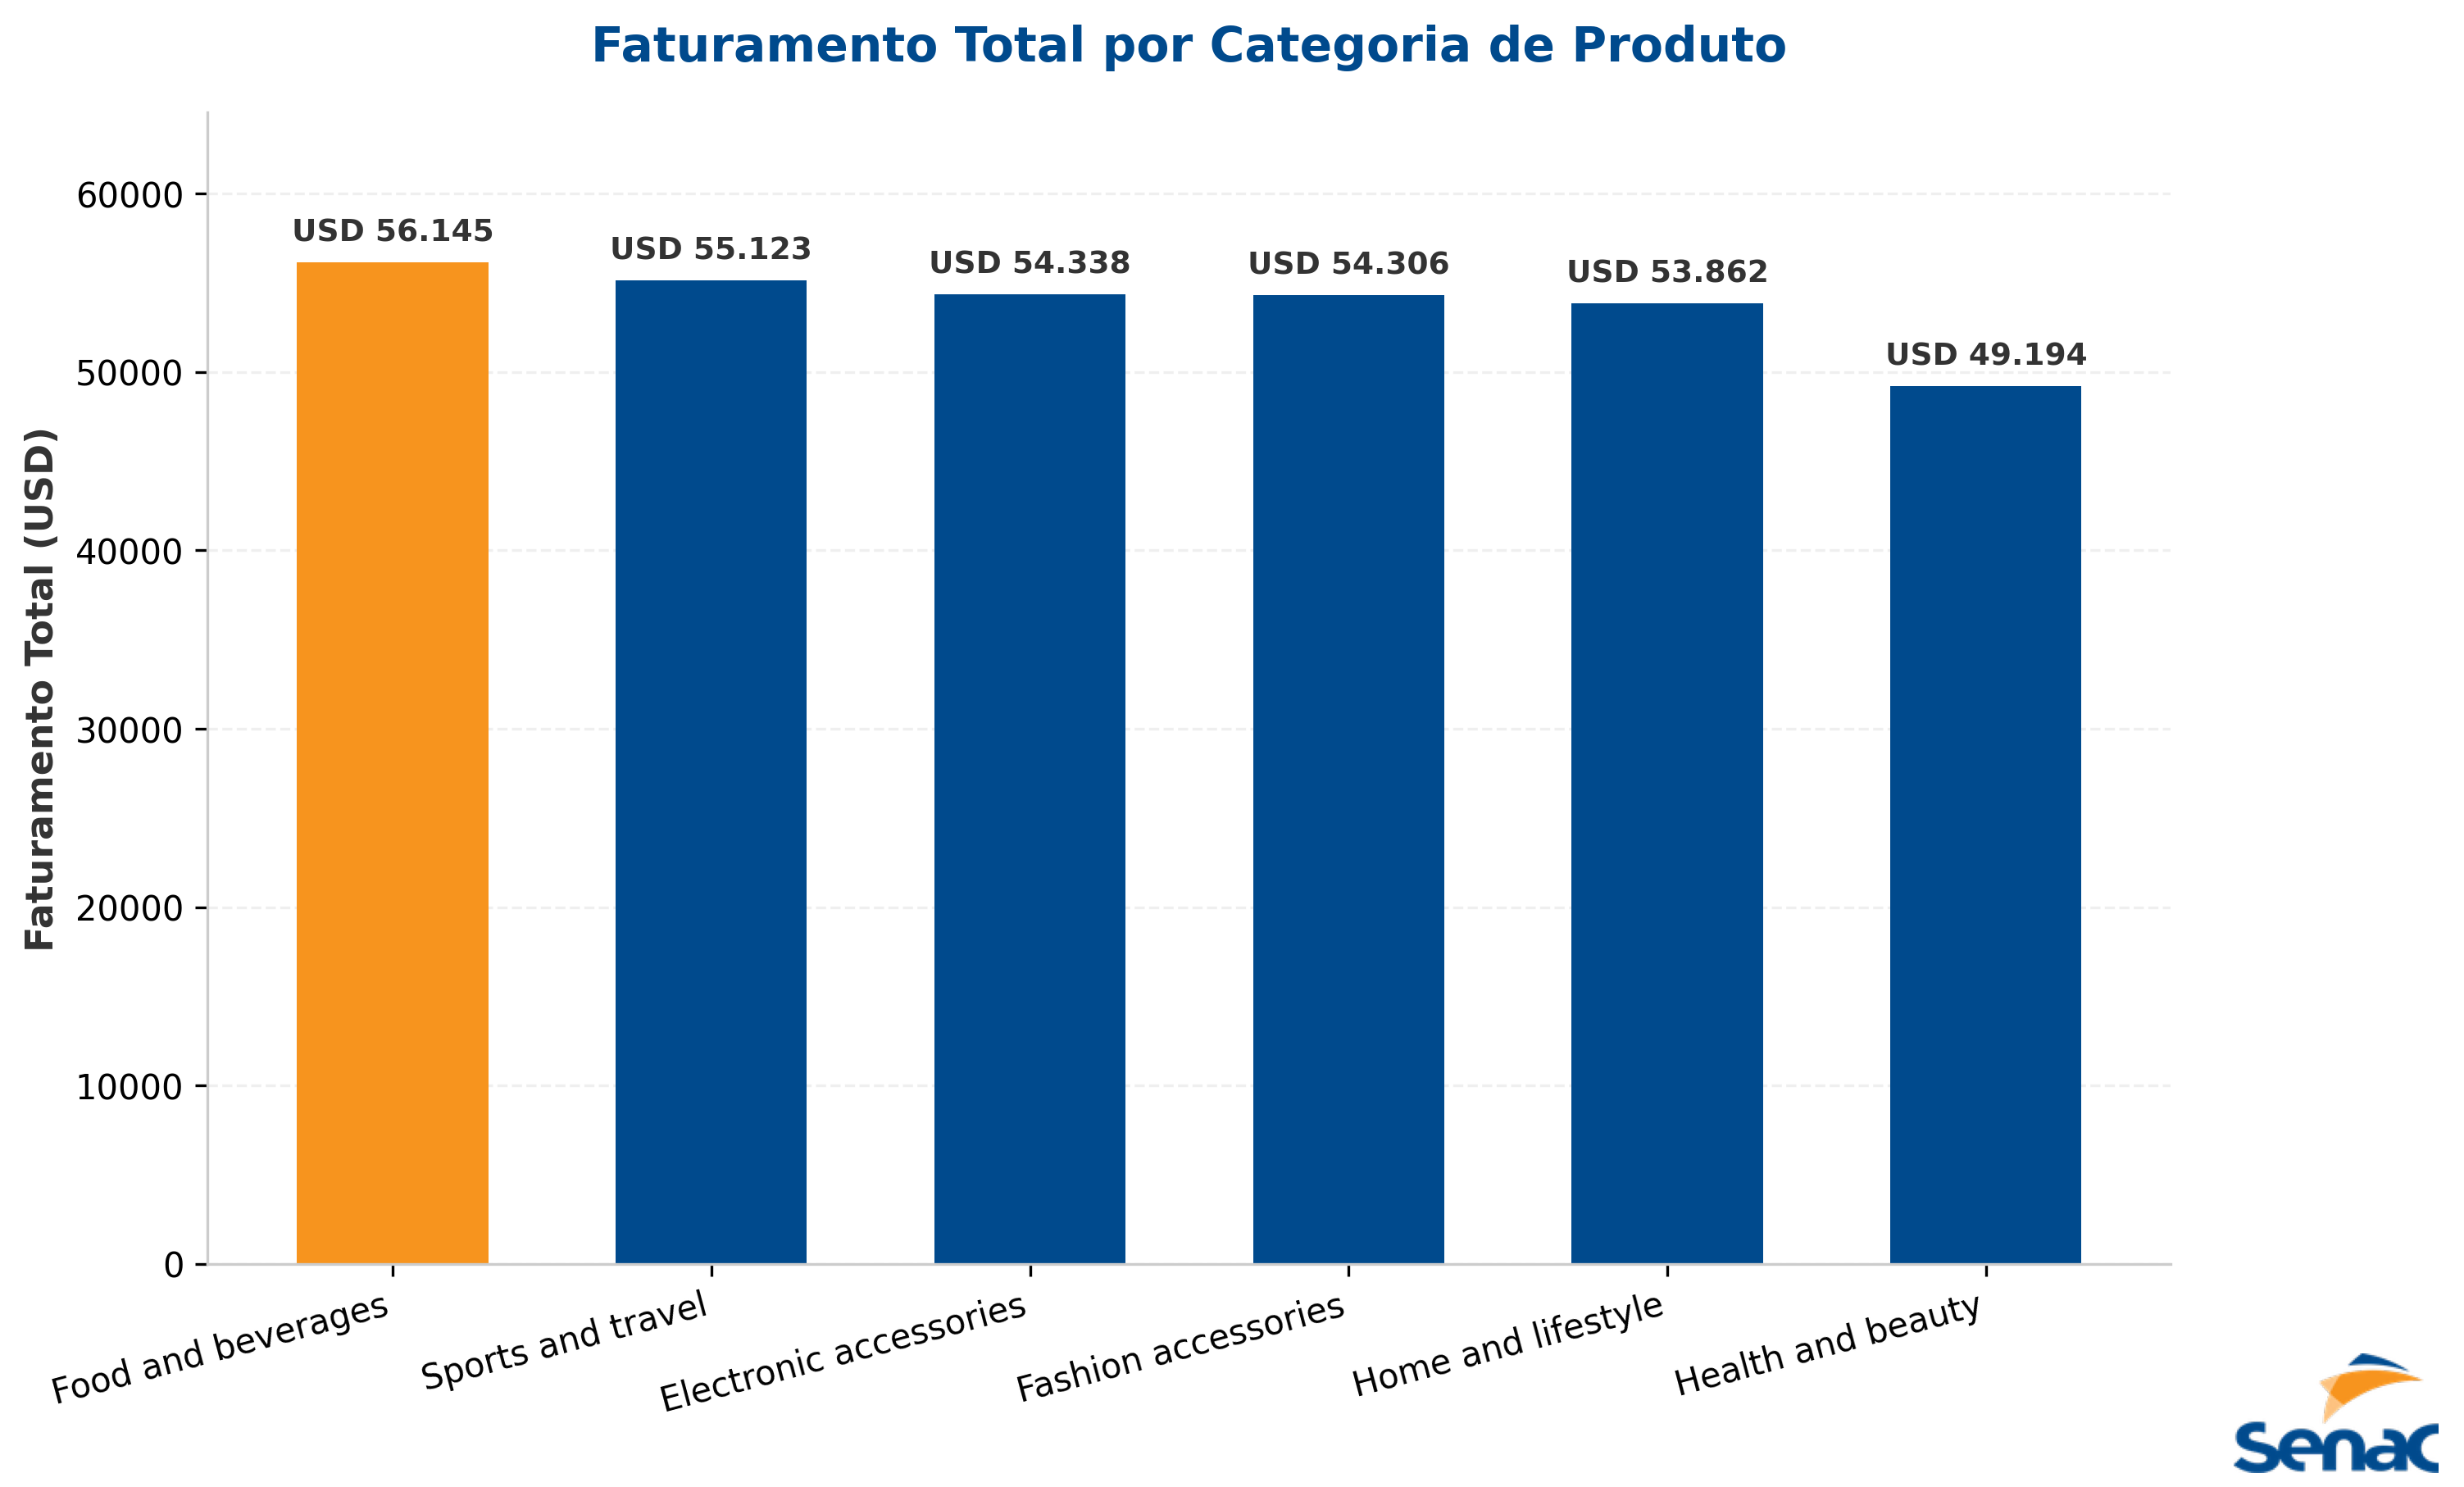

In [60]:
# ==========================
# 1. Faturamento por Categoria de Produto
# ==========================

faturamento_categoria = (
    df.groupby("Product line")["Sales"].sum().sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

cores = [LARANJA_SENAC] + [AZUL_SENAC] * (len(faturamento_categoria) - 1)

bars = ax.bar(
    faturamento_categoria.index,
    faturamento_categoria.values,
    color=cores,
    width=0.6,
)

ax.set_title(
    "Faturamento Total por Categoria de Produto",
    fontsize=14,
    pad=15,
    color=AZUL_SENAC,
    fontweight="bold",
)
ax.set_ylabel(
    "Faturamento Total (USD)", fontsize=11, color="#333333", fontweight="bold"
)

plt.xticks(rotation=15, ha="right", fontsize=10)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + (max(faturamento_categoria.values) * 0.015),
        f"USD {height:,.0f}".replace(",", "."),
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="#333333",
    )

ax.set_ylim(0, max(faturamento_categoria.values) * 1.15)
ax.grid(axis="y", linestyle="--", alpha=0.3, color="#cccccc")
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#cccccc")
ax.spines["bottom"].set_color("#cccccc")

caminho_logo = "logo_senac.png"

try:
    img_logo = Image.open(caminho_logo)

    # Ajusta o tamanho da imagem mantendo alta qualidade (LANCZOS evita a pixelização)
    largura_alvo = 120
    proporcao = largura_alvo / float(img_logo.size[0])
    altura_alvo = int((float(img_logo.size[1]) * float(proporcao)))
    img_logo_resized = img_logo.resize(
        (largura_alvo, altura_alvo), Image.Resampling.LANCZOS
    )

    # Aplica o zoom proporcional
    imagebox = OffsetImage(img_logo_resized, zoom=0.5, resample=True)
    ab = AnnotationBbox(
        imagebox, (0.95, 0.05), xycoords="figure fraction", frameon=False
    )
    ax.add_artist(ab)
except FileNotFoundError:
    pass

plt.tight_layout()
plt.show()

**O que o gráfico mostra:**  
O faturamento total registrado em cada categoria de produto durante o período analisado.

**Qual decisão ele pode ajudar a tomar:**  
- Identificar as categorias que mais contribuem para o faturamento.
- Orientar análises de estoque, exposição e campanhas promocionais.
- Investigar possíveis causas para o menor faturamento de algumas categorias.
- Acompanhar mudanças no desempenho comercial das categorias.

**Por que essa informação é útil:**  
A comparação permite identificar quais categorias possuem maior participação nas vendas. Entretanto, faturamento elevado não significa necessariamente maior rentabilidade ou maior quantidade vendida.

**Principais resultados:**  
Food and beverages apresentou o maior faturamento, com aproximadamente USD 56,1 mil, seguido por Sports and travel, com USD 55,1 mil. Health and beauty apresentou o menor faturamento, com aproximadamente USD 49,2 mil.

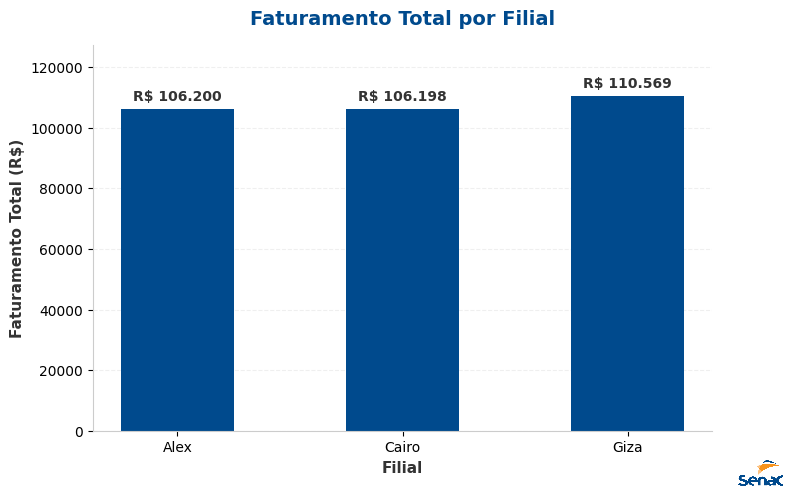

In [56]:
# ==========================
# 2. Faturamento por filial
# ==========================

faturamento_filial = df.groupby('Branch')['Sales'].sum()

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(faturamento_filial.index, faturamento_filial.values, color=AZUL_SENAC, width=0.5)

ax.set_title('Faturamento Total por Filial', fontsize=14, pad=15, color=AZUL_SENAC, fontweight='bold')
ax.set_xlabel('Filial', fontsize=11, color='#333333', fontweight='bold')
ax.set_ylabel('Faturamento Total (R$)', fontsize=11, color='#333333', fontweight='bold')

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + (max(faturamento_filial.values) * 0.015),
        f'R$ {height:,.0f}'.replace(',', '.'),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#333333'
    )

ax.set_ylim(0, max(faturamento_filial.values) * 1.15)
ax.grid(axis='y', linestyle='--', alpha=0.3, color='#cccccc')
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

caminho_logo = 'logo_senac.png'

try:
    img_logo = Image.open(caminho_logo)
    imagebox = OffsetImage(img_logo, zoom=0.08)
    ab = AnnotationBbox(
        imagebox,
        (0.95, 0.05),
        xycoords='figure fraction',
        frameon=False
    )
    ax.add_artist(ab)
except FileNotFoundError:
    pass

plt.tight_layout()
plt.show()

**O que o gráfico mostra:**  
O faturamento total registrado em cada filial durante o período analisado.

**Qual decisão ele pode ajudar a tomar:**  
- Comparar o desempenho comercial das unidades.
- Investigar fatores que podem explicar eventuais diferenças.
- Identificar práticas comerciais que possam ser compartilhadas entre as filiais.
- Apoiar a definição de metas específicas para cada unidade.

**Por que essa informação é útil:**  
A comparação ajuda a identificar diferenças de faturamento entre as filiais. Entretanto, o faturamento isolado não permite concluir se uma unidade é mais eficiente, pois não há informações sobre tamanho, custos, localização ou quantidade de funcionários.

**Principais resultados:**

Giza apresentou o maior faturamento, com aproximadamente USD 110,6 mil. Alex e Cairo registraram cerca de USD 106,2 mil cada, ficando praticamente empatadas. A diferença entre a maior e a menor filial foi de aproximadamente 4,1%.

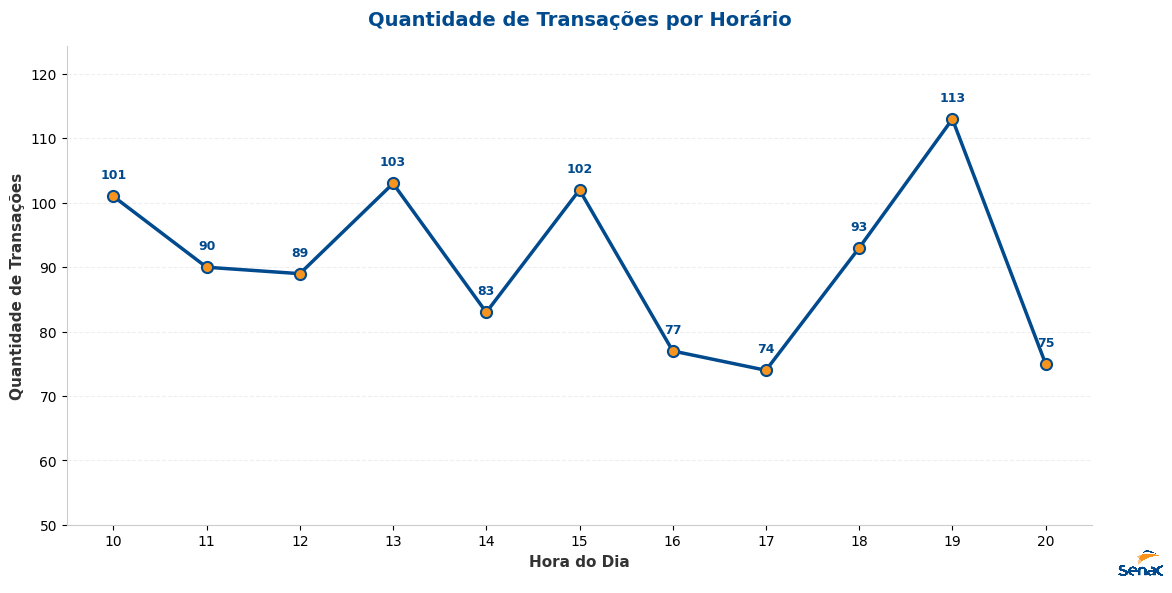

In [57]:
# ==========================
# 3. Quantidade de transações por horário
# ==========================

transacoes_horario = (
    df.groupby('Hour')['Invoice ID']
      .count()
      .sort_index()
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    transacoes_horario.index,
    transacoes_horario.values,
    color=AZUL_SENAC,
    linewidth=2.5,
    marker='o',
    markersize=8,
    markerfacecolor=LARANJA_SENAC,
    markeredgecolor=AZUL_SENAC,
    markeredgewidth=1.5
)

ax.set_title('Quantidade de Transações por Horário', fontsize=14, pad=15, color=AZUL_SENAC, fontweight='bold')
ax.set_xlabel('Hora do Dia', fontsize=11, color='#333333', fontweight='bold')
ax.set_ylabel('Quantidade de Transações', fontsize=11, color='#333333', fontweight='bold')
ax.set_xticks(transacoes_horario.index)

for x, y in zip(transacoes_horario.index, transacoes_horario.values):
    ax.text(
        x,
        y + (max(transacoes_horario.values) * 0.02),
        f'{int(y)}',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color=AZUL_SENAC
    )

ax.set_ylim(50, max(transacoes_horario.values) * 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.3, color='#cccccc')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

caminho_logo = 'logo_senac.png'

try:
    img_logo = Image.open(caminho_logo)
    imagebox = OffsetImage(img_logo, zoom=0.08)
    ab = AnnotationBbox(
        imagebox,
        (0.95, 0.05),
        xycoords='figure fraction',
        frameon=False
    )
    ax.add_artist(ab)
except FileNotFoundError:
    pass

plt.tight_layout()
plt.show()

**O que o gráfico mostra:**  
A quantidade de transações realizadas em cada horário de funcionamento.

**Qual decisão ele pode ajudar a tomar:**  
- Identificar os horários com maior movimento de vendas.
- Ajustar a escala de funcionários conforme a demanda.
- Planejar reposição de produtos e intervalos da equipe.
- Desenvolver promoções para horários com menor movimento.

**Por que essa informação é útil:**  
A quantidade de transações funciona como um indicador do movimento operacional da loja e ajuda no planejamento da equipe.

**Principais resultados:**  
O maior movimento ocorreu às 19h, com 113 transações. O menor ocorreu às 17h, com 74 transações. Os horários de 10h, 13h e 15h também apresentaram mais de 100 transações.

> A quantidade de transações não representa necessariamente o número exato de clientes, pois uma mesma pessoa pode realizar mais de uma compra.

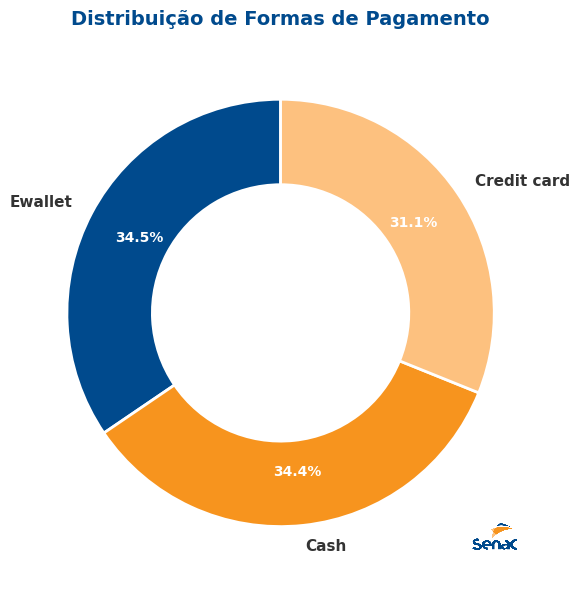

In [58]:
# ==========================
# 4. Formas de pagamento utilizadas
# ==========================

pagamento = df['Payment'].value_counts()

fig, ax = plt.subplots(figsize=(8, 6))

paleta_rosca = [AZUL_SENAC, LARANJA_SENAC, LARANJA_CLARO]

wedges, texts, autotexts = ax.pie(
    pagamento.values,
    labels=pagamento.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=paleta_rosca,
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),
    pctdistance=0.75
)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(10)

for text in texts:
    text.set_color('#333333')
    text.set_fontsize(11)
    text.set_fontweight('bold')

ax.set_title('Distribuição de Formas de Pagamento', fontsize=14, pad=15, color=AZUL_SENAC, fontweight='bold')

caminho_logo = 'logo_senac.png'

try:
    img_logo = Image.open(caminho_logo)
    imagebox = OffsetImage(img_logo, zoom=0.08)

    ab = AnnotationBbox(
        imagebox,
        (0.90, 0.08),
        xycoords='axes fraction',
        frameon=False
    )
    ax.add_artist(ab)
except Exception as e:
    print(f"Erro ao carregar a logo: {e}")

plt.tight_layout()
plt.show()

**O que o gráfico mostra:**  
A quantidade de transações realizadas por carteira digital, dinheiro e cartão de crédito.

**Qual decisão ele pode ajudar a tomar:**  
- Manter disponíveis diferentes formas de pagamento.
- Avaliar os custos e as condições de cada modalidade.
- Planejar promoções relacionadas aos meios de pagamento.
- Acompanhar possíveis mudanças no comportamento dos clientes.

**Por que essa informação é útil:**  
A análise permite conhecer a distribuição das transações entre os meios de pagamento e verificar se existe concentração em alguma modalidade.

**Principais resultados:**  
As formas de pagamento apresentaram distribuição relativamente equilibrada. A carteira digital foi utilizada em 345 transações, o dinheiro em 344 e o cartão de crédito em 311. Portanto, não foi identificada uma preferência dominante.

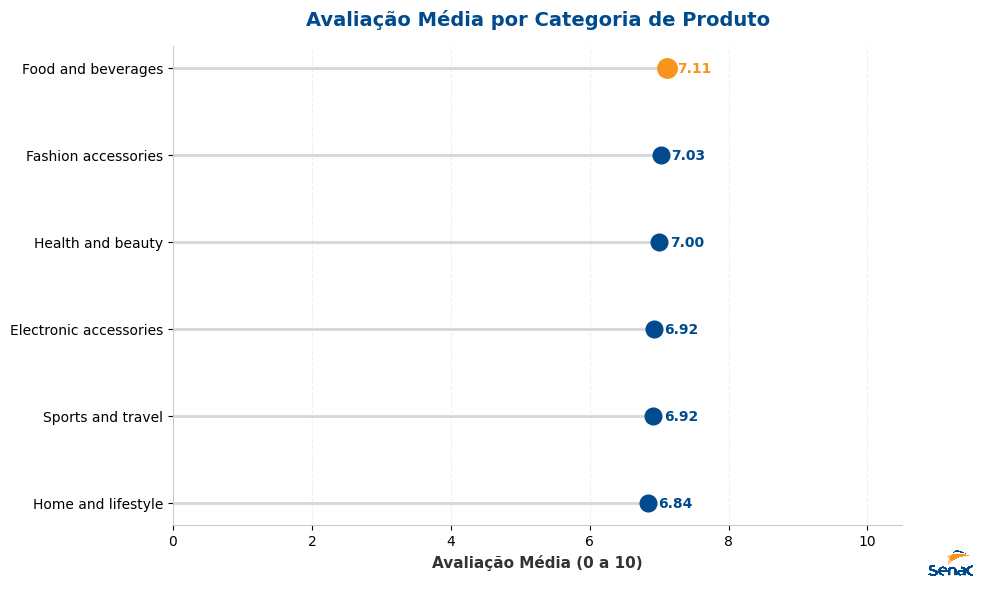

In [59]:
# ==========================
# 5. Avaliação média por categoria de produto
# ==========================

avaliacao_categoria = (
    df.groupby('Product line')['Rating']
      .mean()
      .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.hlines(
    y=avaliacao_categoria.index,
    xmin=0,
    xmax=avaliacao_categoria.values,
    color='#cccccc',
    alpha=0.8,
    linewidth=2
)

ax.plot(
    avaliacao_categoria.values,
    avaliacao_categoria.index,
    "o",
    markersize=12,
    color=AZUL_SENAC
)

maior_valor = avaliacao_categoria.max()
categoria_maior = avaliacao_categoria.idxmax()
ax.plot(
    maior_valor,
    categoria_maior,
    "o",
    markersize=14,
    color=LARANJA_SENAC
)

ax.set_title('Avaliação Média por Categoria de Produto', fontsize=14, pad=15, color=AZUL_SENAC, fontweight='bold')
ax.set_xlabel('Avaliação Média (0 a 10)', fontsize=11, color='#333333', fontweight='bold')

for i, (categoria, valor) in enumerate(zip(avaliacao_categoria.index, avaliacao_categoria.values)):
    ax.text(
        valor + 0.15,
        i,
        f'{valor:.2f}',
        va='center',
        fontsize=10,
        fontweight='bold',
        color=LARANJA_SENAC if valor == maior_valor else AZUL_SENAC
    )

ax.set_xlim(0, 10.5)
ax.grid(axis='x', linestyle='--', alpha=0.3, color='#cccccc')
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

caminho_logo = 'logo_senac.png'

try:
    img_logo = Image.open(caminho_logo)
    imagebox = OffsetImage(img_logo, zoom=0.08)
    ab = AnnotationBbox(
        imagebox,
        (0.95, 0.05),
        xycoords='figure fraction',
        frameon=False
    )
    ax.add_artist(ab)
except FileNotFoundError:
    pass

plt.tight_layout()
plt.show()

**O que o gráfico mostra:**  
A avaliação média atribuída pelos clientes a cada categoria de produto.

**Qual decisão ele pode ajudar a tomar:**  
- Identificar categorias com avaliações inferiores às demais.
- Investigar possíveis problemas relacionados à qualidade, variedade, preço ou experiência de compra.
- Acompanhar a satisfação dos clientes após a realização de melhorias.

**Por que essa informação é útil:**  
A visualização acrescenta a perspectiva dos clientes à análise financeira. Entretanto, as diferenças entre as categorias são pequenas e, isoladamente, não comprovam a existência de problemas.

**Resultado observado:**  
A categoria *Food and beverages* apresentou a maior avaliação média, aproximadamente 7,11. Já *Home and lifestyle* apresentou a menor, aproximadamente 6,84. Como a diferença é de apenas 0,27 ponto, recomenda-se investigar outros períodos e informações antes de tomar uma decisão definitiva.

## 5. Conclusão

### Conclusão Geral das Análises

A partir das visualizações geradas, é possível identificar pontos importantes sobre o desempenho do supermercado:

### 1. Faturamento por categoria de produto
Food and beverages apresentou o maior faturamento, com aproximadamente USD 56,1 mil, seguido por Sports and travel, com USD 55,1 mil. Health and beauty registrou o menor resultado, com aproximadamente USD 49,2 mil. Esses dados ajudam a identificar a participação comercial das categorias, mas devem ser combinados com informações de estoque, custos e quantidade vendida antes de orientar mudanças no mix de produtos.

### 2. Faturamento por filial
Giza apresentou o maior faturamento, com aproximadamente USD 110,6 mil. Alex e Cairo registraram valores próximos de USD 106,2 mil. Embora Giza tenha apresentado resultado ligeiramente superior, seria necessário analisar períodos adicionais e as características de cada unidade antes de recomendar investimentos ou ações corretivas.

### 3. Quantidade de transações por horário
A quantidade de transações varia ao longo do dia. O maior movimento foi registrado às 19h, com 113 transações, enquanto o menor ocorreu às 17h, com 74. Esses resultados podem auxiliar no planejamento da escala de funcionários, da reposição de produtos e de ações promocionais. Entretanto, seria necessário analisar um período maior antes de alterar definitivamente a operação da loja.

### 4. Formas de pagamento utilizadas
As formas de pagamento apresentaram distribuição equilibrada. A carteira digital representou 34,5% das transações, o dinheiro 34,4% e o cartão de crédito 31,1%. Os resultados não indicam uma preferência dominante, reforçando a importância de manter as três modalidades disponíveis.

### 5. Avaliação média por categoria de produto
As avaliações médias das categorias ficaram próximas entre si. A categoria Food and beverages apresentou a maior média, aproximadamente 7,11, enquanto Home and lifestyle apresentou a menor, aproximadamente 6,84. Como a diferença é pequena, os resultados servem como indicação inicial para novas investigações, mas não justificam isoladamente mudanças comerciais.

---

### Conclusão Final

De forma geral, as análises mostram que o supermercado possui categorias e filiais que impulsionam o faturamento, enquanto outras apresentam potencial de melhoria. A distribuição dos horários e das formas de pagamento revela padrões importantes de comportamento dos clientes. A análise das avaliações complementa os resultados financeiros ao apresentar uma visão inicial da satisfação dos clientes em cada categoria.

Esses insights ajudam a direcionar decisões de estoque, marketing, operação e estratégia comercial de forma mais eficiente e orientada por dados.